<a href="https://colab.research.google.com/github/ay2559103-lang/ecommerce-sales-analytics/blob/main/E_Commerce_Sales_Analytics_Dashboard_using_Python%2C_Pandas%2C_NumPy_and_Matplotlib%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

***# E-Commerce Sales Analytics Dashboard

This project analyzes sales performance using Python, Pandas, NumPy, and Matplotlib.

Objectives:
- Clean and prepare data
- Analyze sales trends
- Compare category performance
- Identify outliers
- Build visual dashboards
- Generate business insights***

In [10]:
import os
for root , dirs, files in os.walk("vivek468/superstore-datasfinalet-|"):
  for file in files:
    print(os.path.join(root, file))

In [ ]:
import pandas as pd
import os

# The 'path' variable from kagglehub.dataset_download contains the directory where the dataset is downloaded.
# It is defined in cell aK0bQ9Ot1fF3 as: path = '/kaggle/input/superstore-dataset-final'

# List the contents of the downloaded directory to find the CSV file
dataset_files = os.listdir(path)
csv_file = None
for file in dataset_files:
    if file.endswith(".csv"):
        csv_file = os.path.join(path, file)
        break

if csv_file:
    # Try reading with 'latin1' encoding to handle UnicodeDecodeError
    try:
        df = pd.read_csv(csv_file, encoding='latin1')
        print(df.head())
    except UnicodeDecodeError:
        print(f"UnicodeDecodeError: Could not decode file with latin1 encoding. Try another encoding if available.")
        # Optionally, you could try another encoding like 'cp1252'
        # df = pd.read_csv(csv_file, encoding='cp1252')
        # print(df.head())
else:
    print(f"No CSV file found in the directory: {path}")

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [ ]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [ ]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
df.duplicated().sum()

np.int64(0)

***Statistics using numpy***

In [ ]:
sales = df["Sales"]

In [ ]:
np.mean(sales)  # average order value of sales

np.float64(229.85800083049833)

In [ ]:
np.median(sales) #middle value after sorting

np.float64(54.489999999999995)

In [ ]:
np.std(sales)

623.2139187650471

In [ ]:
np.percentile(sales, 95) #95% of orders are below that value

np.float64(956.9842450000003)

In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [ ]:
df["Month"] = df["Order Date"].dt.to_period("M")

In [ ]:
monthly_sales = df.groupby("Month")["Sales"].sum

In [ ]:
monthly_sales = df.groupby("Month")["Sales"].sum()
print(monthly_sales)

Month
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
2017-07     45264.4160
2017-

In [ ]:
monthly_sales.sum()

np.float64(2297200.8603)

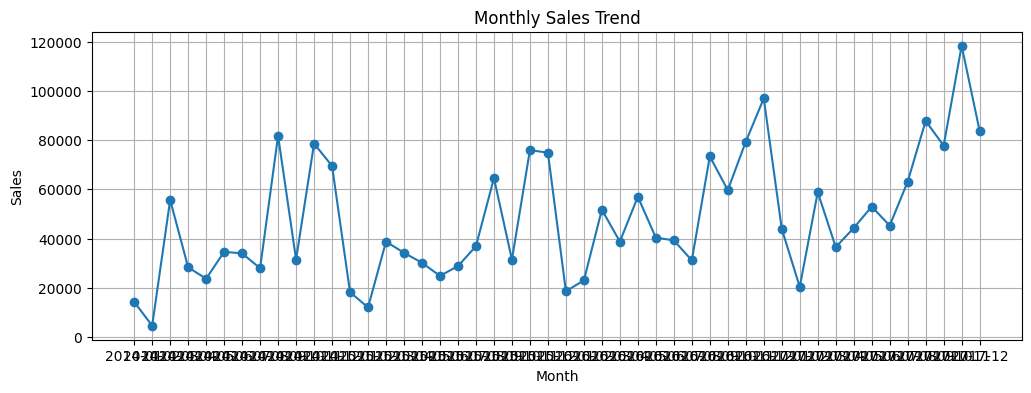

In [ ]:
plt.figure(figsize=(12, 4))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

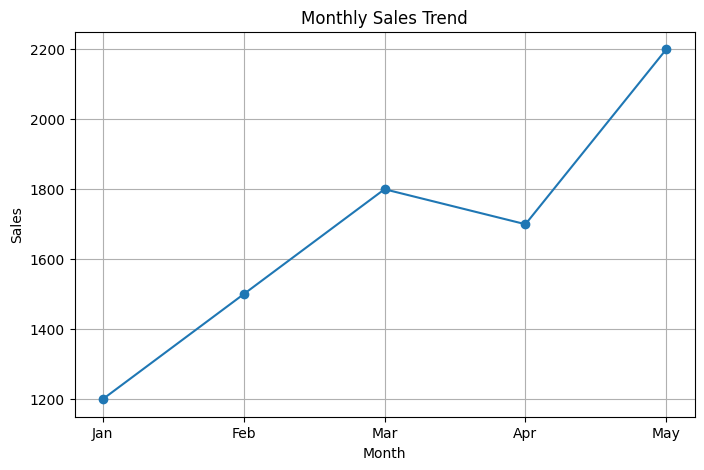

In [3]:
import matplotlib.pyplot as plt #trends overtime

months = ["Jan","Feb","Mar","Apr","May"]
sales = [1200,1500,1800,1700,2200]

plt.figure(figsize=(8,5))

plt.plot(months, sales, marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

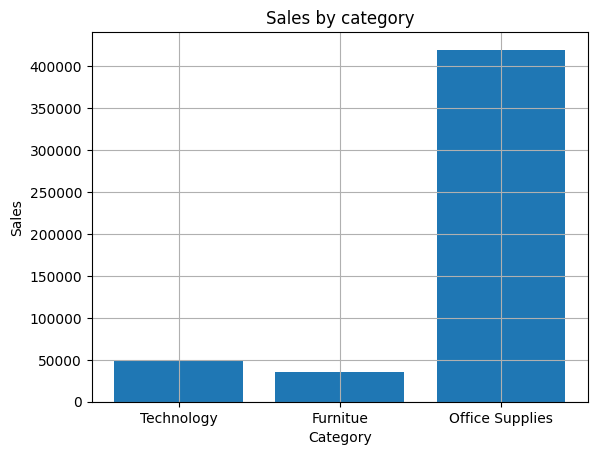

In [4]:
##comparing categories
categories = ["Technology","Furnitue","Office Supplies"]
sales = [50000, 35000,420000]

plt.bar(categories, sales)

plt.title("Sales by category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.grid(True)

plt.show()


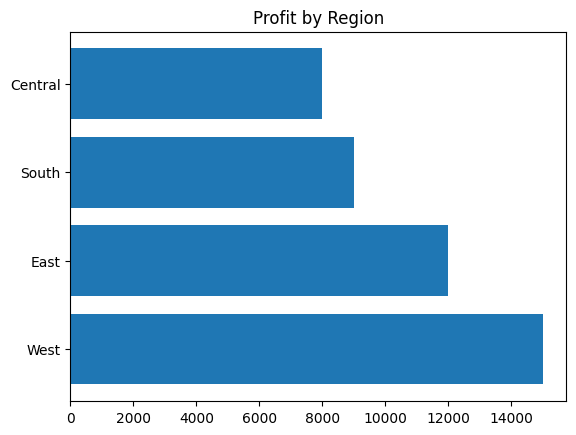

In [5]:
#Horizontal bar plot
regions = ["West","East","South","Central"]
profit = [15000,12000,9000,8000]

plt.barh(regions, profit)

plt.title("Profit by Region")
plt.show()

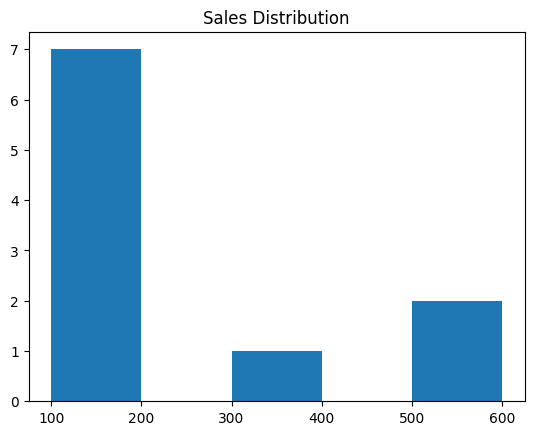

In [6]:
##Distribution Analysis
sales = [100,120,130,150,160,170,180,300,500,600]

plt.hist(sales, bins=5)

plt.title("Sales Distribution")
plt.show()

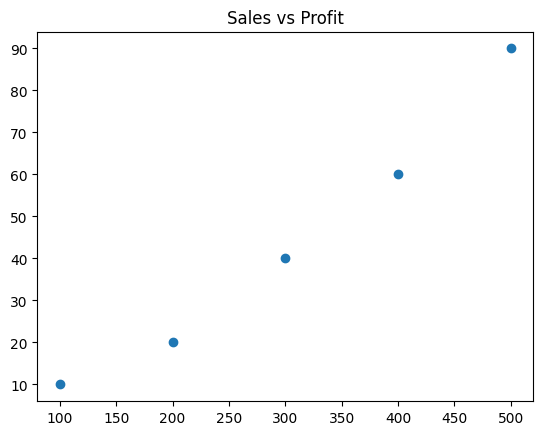

In [7]:
# relationship between variables
sales = [100,200,300,400,500]
profit = [10,20,40,60,90]

plt.scatter(sales, profit)

plt.title("Sales vs Profit")
plt.show()

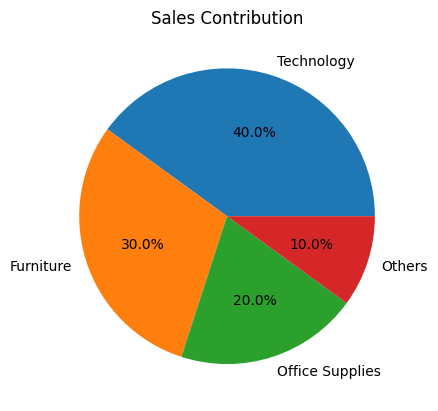

In [14]:
sales = [40,30,20,10]

labels = [
    "Technology",
    "Furniture",
    "Office Supplies",
    "Others"
]

plt.pie(
    sales,
    labels=labels,
    autopct="%1.1f%%"
)

plt.title("Sales Contribution")

plt.show()














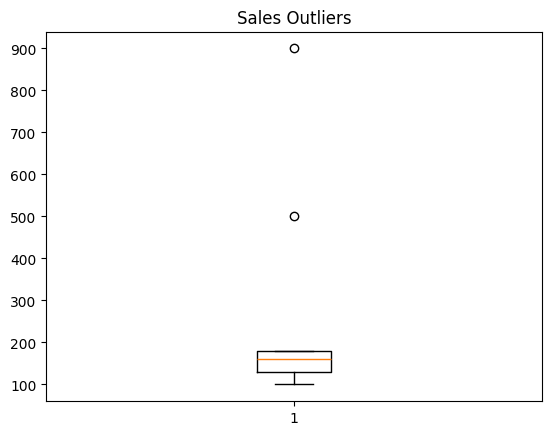

In [15]:
sales = [100,120,130,150,160,170,180,500,900]

plt.boxplot(sales)

plt.title("Sales Outliers")

plt.show()

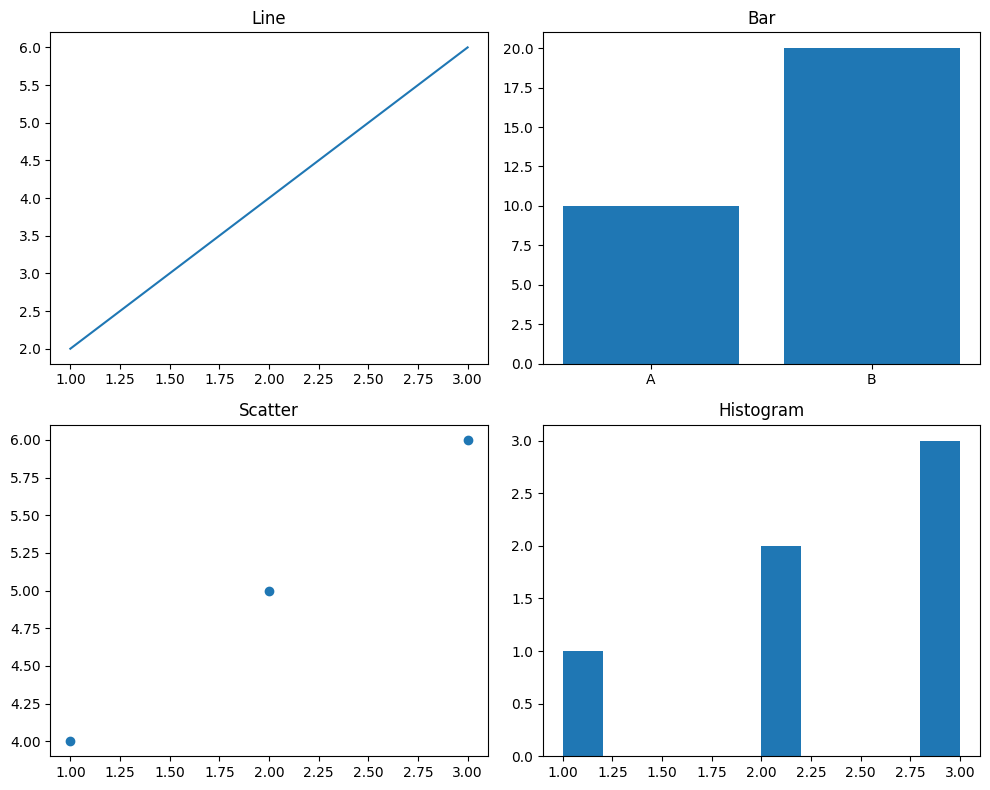

In [16]:
plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.plot([1,2,3],[2,4,6])
plt.title("Line")

plt.subplot(2,2,2)
plt.bar(["A","B"],[10,20])
plt.title("Bar")

plt.subplot(2,2,3)
plt.scatter([1,2,3],[4,5,6])
plt.title("Scatter")

plt.subplot(2,2,4)
plt.hist([1,2,2,3,3,3])
plt.title("Histogram")

plt.tight_layout()

plt.show()